Author: [Mohit Saharan](https://linkedin.com/in/msaharan)

# Tabular foundation models: comparing TabICL, TabPFN, and classical supervised ML

This notebook explores TabPFN and TabICL through hands-on examples and compares them with the classical supervised ML models. 

References used while preparing this notebook:

- Examples given in the TabICL GitHub repository (commit: 3b0c68074933bb3a602f757901dea4dc228ff84f) and the example notebook given in TabPFN GitHub repository (commit: eaefd29252a0897bd644c1840934b34ce08e194f)

## Notebook scope

We will cover four supervised examples:

1. Binary classification on the breast cancer dataset.
2. Regression on the diabetes dataset.
3. Classification probability surfaces on a noisy two-moons dataset.
4. Quantile regression on a heteroscedastic 1D dataset.

The first two examples are benchmark-style comparisons. The last two examples are behavior diagnostics: they show probability surfaces and predictive intervals rather than only one score.

Kaggle note: enable Internet before running this notebook. `tabicl` and `tabpfn` download pretrained checkpoints on first use.

In [21]:
# Kaggle / Colab setup.
# If imports fail after installation, restart the kernel and run from the imports cell.
# !uv pip install -q -U tabicl tabpfn tabpfn-client xgboost catboost datasets rich 

## Base library Installation
# Install Baselines for model comparison
!uv pip install catboost xgboost

# Install the datasets library for loading example data
!uv pip install datasets

# Install rich for better and more readable printing
!uv pip install rich

## TabPFN Installation optimized for Google Colab
# Install the TabPFN Client library
!uv pip install tabpfn-client

# Install TabPFN extensions for additional functionalities
!uv pip install 'tabpfn-extensions[all]'

# Install tabpfn
!uv pip install tabpfn

# Install tabicl
!uv pip install tabicl

Using Python 3.12.12 environment at: /usr
Audited 2 packages in 126ms
Using Python 3.12.12 environment at: /usr
Resolved 45 packages in 189ms                                        
Prepared 1 package in 602ms                                              
Uninstalled 1 package in 12ms
Installed 1 package in 29ms                                 
 - pyarrow==20.0.0
 + pyarrow==24.0.0
Using Python 3.12.12 environment at: /usr
Audited 1 package in 123ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 124ms
Using Python 3.12.12 environment at: /usr
Resolved 107 packages in 88ms                                        
Uninstalled 1 package in 12ms
Installed 1 package in 17ms                                 
 - pyarrow==24.0.0
 + pyarrow==20.0.0
Using Python 3.12.12 environment at: /usr
Audited 1 package in 132ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 128ms


# Necessary Imports for the Notebook [Running this cell required!]

Now that the libraries are installed, let's import all the necessary modules for this notebook.

In [22]:
# Standard Library Imports
import os
import time
import warnings

# Hugging Face authentication for TabICL checkpoint downloads.
# In Kaggle, add a secret named HF_TOKEN. The checkpoint is public, so this
# is optional, but it avoids anonymous-request warnings and lower rate limits.
hf_token = os.environ.get("HF_TOKEN")

if not hf_token:
    try:
        from kaggle_secrets import UserSecretsClient

        hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        pass

if not hf_token:
    try:
        from google.colab import userdata

        hf_token = userdata.get("HF_TOKEN")
    except Exception:
        pass

if hf_token:
    os.environ["HF_TOKEN"] = hf_token
    print("HF_TOKEN found. Hugging Face downloads will use authenticated requests.")
else:
    print("HF_TOKEN not found. Hugging Face downloads will use anonymous requests.")

# TabPFN and Extensions

try:
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import (
        AutoTabPFNClassifier,
    )

    from tabpfn import TabPFNClassifier, TabPFNRegressor
except ImportError:
    raise ImportError(
        "Warning: Could not import TabPFN / TabPFN extensions. Please run installation above and restart the session afterwards (Runtime > Restart Session)."
    )

from tabicl import TabICLClassifier, TabICLRegressor

# Data Science & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.special import expit

# Other ML Models
from catboost import CatBoostClassifier, CatBoostRegressor

# Notebook UI/Display
from IPython.display import Markdown, display
from rich.console import Console
from rich.panel import Panel
from rich.rule import Rule
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import make_column_selector, make_column_transformer

# Scikit-Learn: Data & Preprocessing
from sklearn.datasets import fetch_openml, load_breast_cancer, load_diabetes, make_moons

# Scikit-Learn: Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    RepeatedKFold,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBClassifier, XGBRegressor

# This transformer will be used to handle categorical features for the baseline models
column_transformer = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        make_column_selector(dtype_include=["object", "category"]),
    ),
    remainder="passthrough",
)

warnings.filterwarnings("ignore")

HF_TOKEN found. Hugging Face downloads will use authenticated requests.


# Backend Selection [Running this cell required!]

TabPFN can be run in two ways: locally on your machine (if you have a GPU) or by using the TabPFN client, which sends the data to a server for computation.
In your project you would either use the **local** version (which requires a GPU) with:
```python
# Simple import for TabPFN
from tabpfn import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

or the **client** API (which uses a remote server):

```python
# Simple import for TabPFN
from tabpfn_client import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

If you select **local** and it's your first time using the model, you'll need to accept the license agreement and log into Hugging Face.
You'll be prompted with instructions on how to do this the first time you fit the model.

For demonstration purposes, the cell below provides an interactive way to switch between local mode and the client:


In [23]:
# Authentication code - No need to read it!

console = Console()

console.print(Panel.fit("[bold magenta]TabPFN Demo: Backend Selection[/bold magenta]"))
console.print("\nThis script can run TabPFN using one of two backends:")
console.print("  [bold]local:[/bold] Uses a local GPU (NVIDIA). Requires CUDA.")
console.print(
    "  [bold]client:[/bold] Uses the TabPFN API. Requires an internet connection and a free account."
)

backend = "local"
# backend = None
while backend is None:
  console.print(
      "\n[bold]Choose your backend[/bold]: - If no text box is shown, restart the cell.",
  )
  user_input = input("Enter 'local' or 'client' and press return:")
  if user_input not in ["local", "client"]:
    continue
  backend = user_input

console.print(
    f"\n✅ You have selected the '[bold green]{backend}[/bold green]' backend."
)

console.print(Rule(f"[bold]Setting up [cyan]{backend}[/cyan] backend[/bold]"))

if backend == "local":
    console.print("Attempting local backend setup...")
    import torch

    if not torch.cuda.is_available():
        console.print(
            "[bold red]Error:[/bold red] GPU device not found. For fast training, please enable GPU.",
            style="red",
        )
        console.print(
            "In Colab: Go to [bold]Runtime -> Change runtime type -> Hardware accelerator -> GPU.[/bold]",
            style="yellow",
        )
        raise SystemError("GPU device not found.")
    console.print("[bold green]✅ GPU is available.[/bold green]")

    # --- Prior Labs Authentication ---
    console.print(Rule("[bold]Prior Labs Authentication[/bold]"))
    console.print(
        "\nTabPFN model weights require a free [bold]Prior Labs account[/bold] and "
        "acceptance of the non-commercial license.\n"
    )

    import os
    import getpass

    tabpfn_token = None

    # 1. Try Colab secret TABPFN_TOKEN
    try:
        from kaggle_secrets import UserSecretsClient
        tabpfn_token = UserSecretsClient().get_secret("TABPFN_TOKEN")
        if tabpfn_token:
            os.environ["TABPFN_TOKEN"] = tabpfn_token
            console.print("[bold green]✅ Found TABPFN_TOKEN in Kaggle secrets.[/bold green]")
    except Exception:
        pass
        
    # 2. Try Colab secret TABPFN_TOKEN
    try:
        from google.colab import userdata
        tabpfn_token = userdata.get("TABPFN_TOKEN")
        if tabpfn_token:
            os.environ["TABPFN_TOKEN"] = tabpfn_token
            console.print("[bold green]✅ Found TABPFN_TOKEN in Colab secrets.[/bold green]")
    except Exception:
        pass

    # 3. If no token found, prompt the user
    if not tabpfn_token:
        console.print(
            Panel(
                "To get your access token:\n\n"
                "  1. Go to [link=https://ux.priorlabs.ai]ux.priorlabs.ai[/link] and sign up / log in\n"
                "  2. Accept the license at [link=https://ux.priorlabs.ai/account/licenses]ux.priorlabs.ai/account/licenses[/link]\n"
                "  3. Copy your Access Token from [link=https://ux.priorlabs.ai/account]ux.priorlabs.ai/account[/link]\n\n"
                "[bold yellow]Tip:[/bold yellow] Save the token as a Colab secret named "
                "[bold cyan]TABPFN_TOKEN[/bold cyan] to skip this step next time.",
                title="[bold]🔑 Prior Labs Access Token required",
                border_style="blue",
            )
        )
        while not tabpfn_token:
            token_input = getpass.getpass("Paste your TABPFN_TOKEN and press Enter: ")
            if token_input.strip():
                tabpfn_token = token_input.strip()
                os.environ["TABPFN_TOKEN"] = tabpfn_token
            else:
                console.print("[red]Token cannot be empty. Please try again.[/red]")

    console.print("")
    console.print("Importing local TabPFN library...")

    from tabpfn import TabPFNClassifier, TabPFNRegressor

    console.print("[bold green]✅ TabPFN (local) imported successfully.[/bold green]")
elif backend == "client":
    console.print("Attempting client backend setup...")
    console.print("Importing TabPFN client library...")
    from tabpfn_client import TabPFNClassifier, TabPFNRegressor, init

    init()
    console.print("[bold green]✅ TabPFN (client) initialized.[/bold green]")


╭────────────────────────────────╮
│ TabPFN Demo: Backend Selection │
╰────────────────────────────────╯

This script can run TabPFN using one of two backends:

local: Uses a local GPU (NVIDIA). Requires CUDA.

client: Uses the TabPFN API. Requires an internet connection and a free account.

✅ You have selected the 'local' backend.

...

──────────────────────────────────────────── Prior Labs Authentication ────────────────────────────────────────────

TabPFN model weights require a free Prior Labs account and acceptance of the non-commercial license.

✅ Found TABPFN_TOKEN in Kaggle secrets.

Importing local TabPFN library...

✅ TabPFN (local) imported successfully.

In [25]:
SEED = 42

# Keep True while building/debugging the notebook. Set False for final Kaggle figures.
FAST_MODE = True

# Runtime/quality knobs. TabICL's default is 8 estimators, but 4 is a good
# final-demo compromise on Kaggle T4. Use 8 only if runtime is acceptable.
N_TFM_ESTIMATORS = 2 if FAST_MODE else 4
GRID_POINTS_PER_AXIS = 60 if FAST_MODE else 100
HETEROSCEDASTIC_SAMPLES = 1200 if FAST_MODE else 3000

try:
    CUDA_AVAILABLE = torch.cuda.is_available()
    CUDA_DEVICE_COUNT = torch.cuda.device_count() if CUDA_AVAILABLE else 0
except Exception:
    CUDA_AVAILABLE = False
    CUDA_DEVICE_COUNT = 0

if CUDA_AVAILABLE:
    TABICL_DEVICE = "cuda:0"
    TABPFN_DEVICE = [f"cuda:{i}" for i in range(CUDA_DEVICE_COUNT)]
else:
    TABICL_DEVICE = "cpu"
    TABPFN_DEVICE = "cpu"

# Backward-compatible alias for non-foundation-model code and printouts.
DEVICE = TABICL_DEVICE

print(f"CUDA available: {CUDA_AVAILABLE}")
print(f"CUDA device count: {CUDA_DEVICE_COUNT}")
print(f"TabICL device: {TABICL_DEVICE}")
print(f"TabPFN device(s): {TABPFN_DEVICE}")
print(f"TFM ensemble members: {N_TFM_ESTIMATORS}")
print(f"Grid points per axis: {GRID_POINTS_PER_AXIS}")
print(f"Heteroscedastic samples: {HETEROSCEDASTIC_SAMPLES}")

CUDA available: True
CUDA device count: 2
TabICL device: cuda:0
TabPFN device(s): ['cuda:0', 'cuda:1']
TFM ensemble members: 2
Grid points per axis: 60
Heteroscedastic samples: 1200


## Helper functions

The helper functions keep the notebook compact. They also make the comparison fairer: TabICL, TabPFN, Random Forest, XGBoost, and CatBoost are all accessed through the same sklearn-style workflow.

In [26]:
def positive_class_proba(estimator, X):
    proba = estimator.predict_proba(X)
    if proba.ndim != 2 or proba.shape[1] < 2:
        raise ValueError("Expected a two-column probability array for binary classification.")
    return proba[:, 1]


def predict_proba_in_chunks(estimator, X, chunk_size=2048):
    chunks = []
    for start in range(0, X.shape[0], chunk_size):
        stop = start + chunk_size
        chunks.append(positive_class_proba(estimator, X[start:stop]))
    return np.concatenate(chunks)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def coerce_quantile_array(prediction):
    # TabPFN returns a list of arrays for quantiles; TabICL returns a 2D array.
    if isinstance(prediction, list):
        return np.column_stack(prediction)
    return np.asarray(prediction)


def plot_metric_bars(df, metric, title, ascending=True):
    ordered = df.sort_values(metric, ascending=ascending)
    fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)
    ax.barh(ordered["model"], ordered[metric], color="#3b82f6")
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    return fig, ax

In [27]:
def make_classifiers():
    return {
        "TabICLv2": TabICLClassifier(
            n_estimators=N_TFM_ESTIMATORS,
            device=TABICL_DEVICE,
            random_state=SEED,
            batch_size=1 if TABICL_DEVICE == "cpu" else 4,
        ),
        "TabPFN": TabPFNClassifier(
            n_estimators=N_TFM_ESTIMATORS,
            device=TABPFN_DEVICE,
            random_state=SEED,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            tree_method="hist",
            random_state=SEED,
        ),
        "CatBoost": CatBoostClassifier(
            iterations=300,
            depth=4,
            learning_rate=0.05,
            loss_function="Logloss",
            verbose=False,
            random_seed=SEED,
            allow_writing_files=False,
        ),
    }


def make_regressors():
    return {
        "TabICLv2": TabICLRegressor(
            n_estimators=N_TFM_ESTIMATORS,
            device=TABICL_DEVICE,
            random_state=SEED,
            batch_size=1 if TABICL_DEVICE == "cpu" else 4,
        ),
        "TabPFN": TabPFNRegressor(
            n_estimators=N_TFM_ESTIMATORS,
            device=TABPFN_DEVICE,
            random_state=SEED,
        ),
        "RandomForest": RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1,
        ),
        "XGBoost": XGBRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=SEED,
        ),
        "CatBoost": CatBoostRegressor(
            iterations=300,
            depth=4,
            learning_rate=0.05,
            loss_function="RMSE",
            verbose=False,
            random_seed=SEED,
            allow_writing_files=False,
        ),
    }

## 1. Binary classification benchmark

This section follows the supervised comparison style from the TabPFN hands-on demo. The main difference is that TabICLv2 is now part of the model list.

In [28]:
breast = load_breast_cancer(as_frame=True)
X_cls = breast.data
y_cls = breast.target

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.3,
    stratify=y_cls,
    random_state=SEED,
)

print(X_cls.shape)
X_cls.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [29]:
classification_rows = []
fitted_classifiers = {}
classification_probabilities = {}

for name, estimator in make_classifiers().items():
    start = time.perf_counter()
    estimator.fit(X_train_cls, y_train_cls)
    y_pred = estimator.predict(X_test_cls)
    y_proba = positive_class_proba(estimator, X_test_cls)
    elapsed = time.perf_counter() - start

    fitted_classifiers[name] = estimator
    classification_probabilities[name] = y_proba
    classification_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test_cls, y_pred),
            "roc_auc": roc_auc_score(y_test_cls, y_proba),
            "log_loss": log_loss(y_test_cls, y_proba),
            "seconds": elapsed,
        }
    )

classification_summary = pd.DataFrame(classification_rows).sort_values(
    "roc_auc", ascending=False
)
classification_summary

,model,accuracy,roc_auc,log_loss,seconds
4,CatBoost,0.964912,0.997079,0.069511,0.603072
0,TabICLv2,0.959064,0.995619,0.081631,0.912102
3,XGBoost,0.959064,0.994597,0.087124,0.173699
1,TabPFN,0.947368,0.994305,0.093607,0.490125
2,RandomForest,0.941520,0.991384,0.121716,0.762322


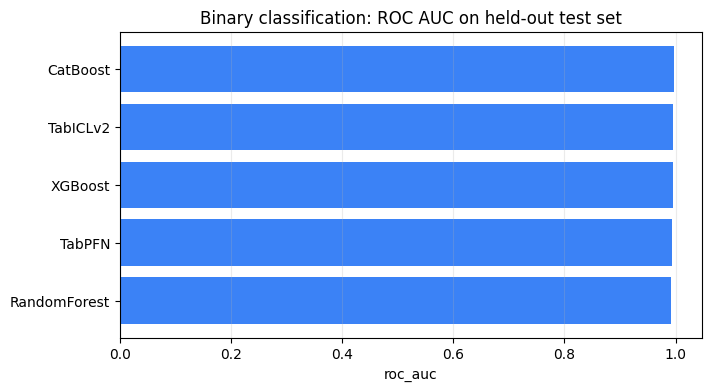

In [30]:
plot_metric_bars(
    classification_summary,
    metric="roc_auc",
    title="Binary classification: ROC AUC on held-out test set",
    ascending=True,
);

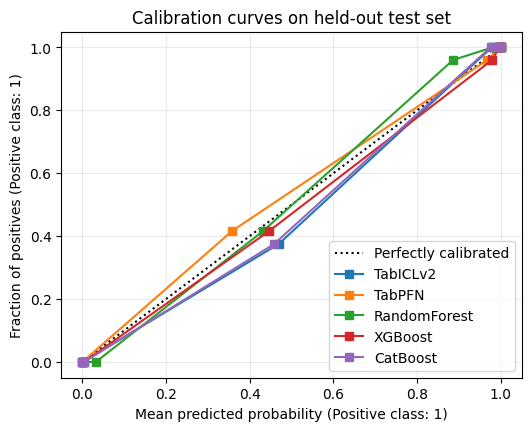

In [31]:
fig, ax = plt.subplots(figsize=(5.2, 4.2), constrained_layout=True)

for name, y_proba in classification_probabilities.items():
    CalibrationDisplay.from_predictions(
        y_test_cls,
        y_proba,
        n_bins=7,
        strategy="quantile",
        name=name,
        ax=ax,
    )

ax.set_title("Calibration curves on held-out test set")
ax.grid(alpha=0.25)
plt.show()

### Optional repeated cross-validation

The TabPFN hands-on demo used repeated cross-validation to make the comparison less dependent on a single split. The cell below keeps that idea, but it is off by default because foundation-model inference can take time on CPU.

In [32]:
RUN_CV_BENCHMARK = True

if RUN_CV_BENCHMARK:
    cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=SEED)
    rows = []
    for name, estimator in make_classifiers().items():
        scores = cross_validate(
            estimator,
            X_cls,
            y_cls,
            cv=cv,
            scoring={"roc_auc": "roc_auc", "accuracy": "accuracy"},
            n_jobs=1,
        )
        rows.append(
            {
                "model": name,
                "roc_auc_mean": scores["test_roc_auc"].mean(),
                "roc_auc_std": scores["test_roc_auc"].std(),
                "accuracy_mean": scores["test_accuracy"].mean(),
                "accuracy_std": scores["test_accuracy"].std(),
            }
        )
    cv_classification_summary = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False)
else:
    cv_classification_summary = pd.DataFrame()
    print("Repeated CV skipped. Set RUN_CV_BENCHMARK = True to run it.")

cv_classification_summary

,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std
0,TabICLv2,0.996451,0.004083,0.982428,0.005819
1,TabPFN,0.996025,0.003629,0.977151,0.008962
4,CatBoost,0.992535,0.006387,0.971002,0.013843
3,XGBoost,0.991121,0.007521,0.960443,0.017431
2,RandomForest,0.988945,0.008230,0.956061,0.012787


## 2. Regression benchmark

TabICLv2 supports regression through `TabICLRegressor`. This was not available in the original TabICLv1. The example below uses the diabetes dataset from scikit-learn so that the notebook does not need to fetch an external dataset.

In [33]:
diabetes = load_diabetes(as_frame=True)
X_reg = diabetes.data
y_reg = diabetes.target

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.3,
    random_state=SEED,
)

print(X_reg.shape)
X_reg.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [34]:
regression_rows = []
fitted_regressors = {}

for name, estimator in make_regressors().items():
    start = time.perf_counter()
    estimator.fit(X_train_reg, y_train_reg)
    y_pred = estimator.predict(X_test_reg)
    elapsed = time.perf_counter() - start

    fitted_regressors[name] = estimator
    regression_rows.append(
        {
            "model": name,
            "rmse": rmse(y_test_reg, y_pred),
            "mae": mean_absolute_error(y_test_reg, y_pred),
            "r2": r2_score(y_test_reg, y_pred),
            "seconds": elapsed,
        }
    )

regression_summary = pd.DataFrame(regression_rows).sort_values("rmse")
regression_summary

,model,rmse,mae,r2,seconds
0,TabICLv2,51.448134,40.463079,0.509678,0.649702
1,TabPFN,51.609647,40.846830,0.506594,0.385544
4,CatBoost,52.064076,41.662406,0.497867,0.124910
2,RandomForest,53.164583,42.415590,0.476415,0.574377
3,XGBoost,55.884744,44.103741,0.421466,0.084082


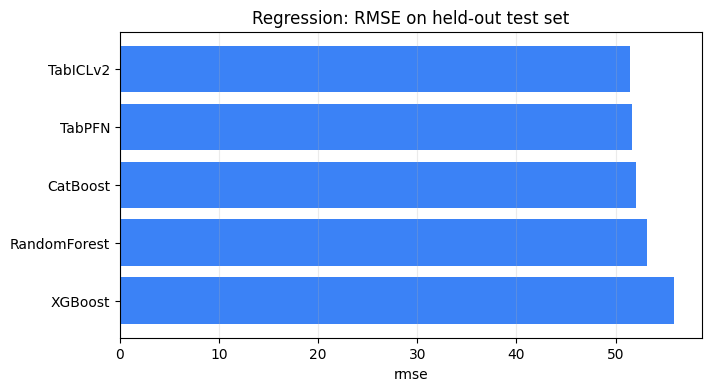

In [35]:
plot_metric_bars(
    regression_summary,
    metric="rmse",
    title="Regression: RMSE on held-out test set",
    ascending=False,
);

## 3. Probability surfaces on a noisy 2D classification problem

This section adapts the TabICL `classification_2D_proba.py` example and extends it into a side-by-side comparison. The point is not just to ask which model has the best score, but how each model distributes class probability across the input space.

In [36]:
X_moons, y_moons = make_moons(n_samples=1000, noise=0.35, random_state=SEED)
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons,
    y_moons,
    test_size=0.25,
    stratify=y_moons,
    random_state=SEED,
)

surface_models = {
    "TabICLv2": TabICLClassifier(
        n_estimators=N_TFM_ESTIMATORS,
        device=TABICL_DEVICE,
        random_state=SEED,
        kv_cache=True,
        batch_size=1 if TABICL_DEVICE == "cpu" else 4,
    ),
    "TabPFN": TabPFNClassifier(
        n_estimators=N_TFM_ESTIMATORS,
        device=TABPFN_DEVICE,
        random_state=SEED,
    ),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
    ),
}

x_min, x_max = X_moons[:, 0].min() - 0.6, X_moons[:, 0].max() + 0.6
y_min, y_max = X_moons[:, 1].min() - 0.6, X_moons[:, 1].max() + 0.6
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, GRID_POINTS_PER_AXIS),
    np.linspace(y_min, y_max, GRID_POINTS_PER_AXIS),
)
grid = np.c_[xx.ravel(), yy.ravel()]

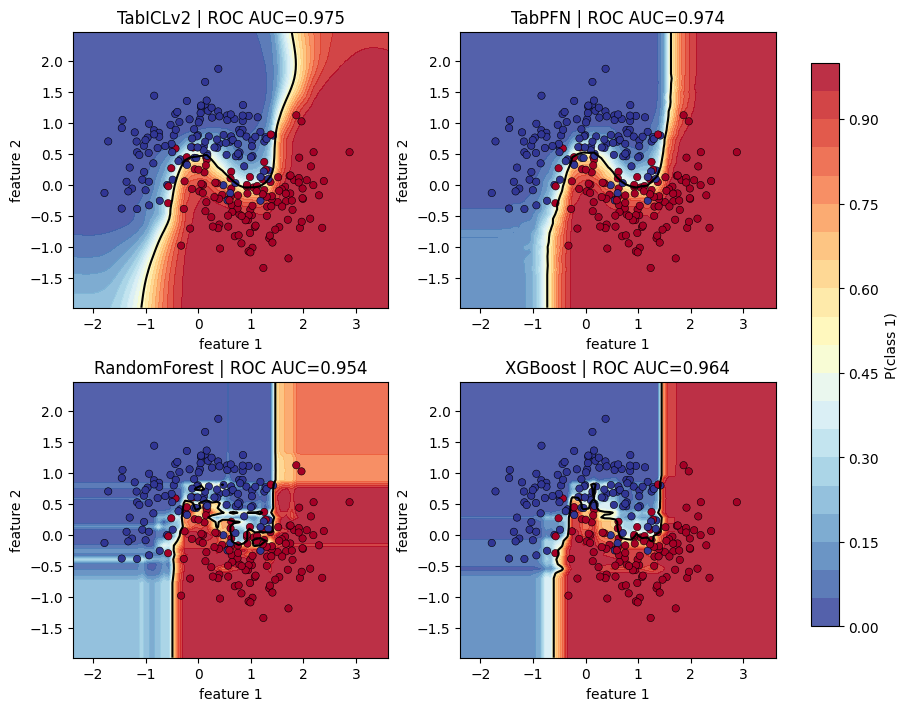

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)
axes = axes.ravel()

for ax, (name, estimator) in zip(axes, surface_models.items()):
    estimator.fit(X_train_moons, y_train_moons)
    test_proba = positive_class_proba(estimator, X_test_moons)
    grid_proba = predict_proba_in_chunks(estimator, grid, chunk_size=2048)
    Z = grid_proba.reshape(xx.shape)

    contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.85)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5)
    ax.scatter(
        X_test_moons[:, 0],
        X_test_moons[:, 1],
        c=y_test_moons,
        cmap="RdYlBu_r",
        edgecolors="black",
        linewidths=0.4,
        s=28,
    )
    auc = roc_auc_score(y_test_moons, test_proba)
    ax.set_title(f"{name} | ROC AUC={auc:.3f}")
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")

fig.colorbar(contour, ax=axes, label="P(class 1)", shrink=0.9)
plt.show()

## 4. Quantile regression on heteroscedastic data

This section adapts the TabICL `regression_heteroscedastic_1D.py` example. The important feature is that `TabICLRegressor` can return quantiles of the predictive distribution. TabPFN's regressor can also return quantiles, so we can compare both models on the same synthetic task.

In [38]:
rng = np.random.default_rng(SEED)
x = rng.uniform(low=-3, high=3, size=HETEROSCEDASTIC_SAMPLES)
X_het = x.reshape(-1, 1)


def true_y_mean(x_values):
    return expit(x_values) - 0.5 - 0.1 * x_values


def true_y_std(x_values):
    return 0.07 * np.exp(-((x_values - 0.5) ** 2) / 0.9)


y_het = rng.normal(loc=true_y_mean(x), scale=true_y_std(x))

X_train_het, X_test_het, y_train_het, y_test_het = train_test_split(
    X_het,
    y_het,
    test_size=0.5,
    random_state=SEED,
)

alphas = [0.10, 0.50, 0.90]

In [39]:
quantile_models = {
    "TabICLv2": TabICLRegressor(
        n_estimators=N_TFM_ESTIMATORS,
        device=TABICL_DEVICE,
        random_state=SEED,
        batch_size=1 if TABICL_DEVICE == "cpu" else 4,
    ),
    "TabPFN": TabPFNRegressor(
        n_estimators=N_TFM_ESTIMATORS,
        device=TABPFN_DEVICE,
        random_state=SEED,
    ),
}

quantile_predictions = {}
quantile_rows = []

for name, estimator in quantile_models.items():
    estimator.fit(X_train_het, y_train_het)
    if name == "TabICLv2":
        q = estimator.predict(X_test_het, output_type="quantiles", alphas=alphas)
    else:
        q = estimator.predict(X_test_het, output_type="quantiles", quantiles=alphas)
    q = coerce_quantile_array(q)
    quantile_predictions[name] = q

    lower, median, upper = q[:, 0], q[:, 1], q[:, 2]
    quantile_rows.append(
        {
            "model": name,
            "median_rmse": rmse(y_test_het, median),
            "interval_10_90_coverage": np.mean((y_test_het >= lower) & (y_test_het <= upper)),
            "mean_interval_width": np.mean(upper - lower),
        }
    )

quantile_summary = pd.DataFrame(quantile_rows)
quantile_summary

,model,median_rmse,interval_10_90_coverage,mean_interval_width
0,TabICLv2,0.033197,0.815000,0.055048
1,TabPFN,0.033077,0.878333,0.058422


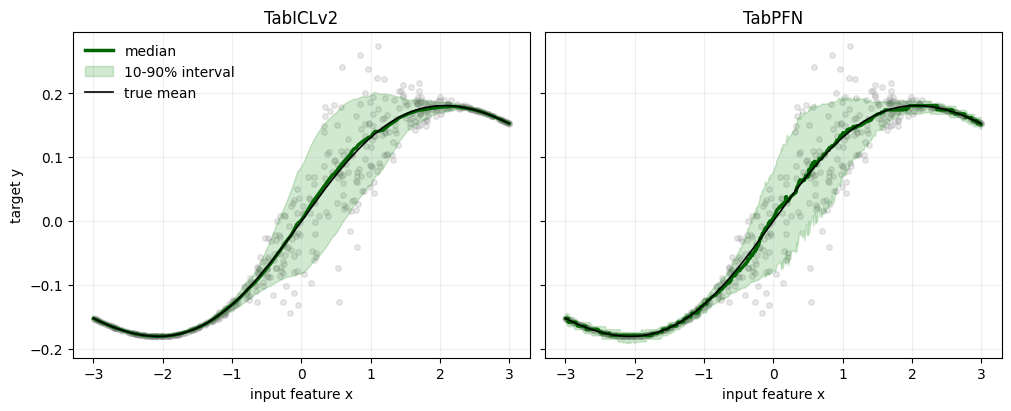

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)

for ax, (name, q) in zip(axes, quantile_predictions.items()):
    order = np.argsort(X_test_het[:, 0])
    x_sorted = X_test_het[order, 0]
    q_sorted = q[order]

    ax.scatter(X_test_het[:, 0], y_test_het, alpha=0.18, s=16, color="gray")
    ax.plot(x_sorted, q_sorted[:, 1], color="darkgreen", linewidth=2.5, label="median")
    ax.fill_between(
        x_sorted,
        q_sorted[:, 0],
        q_sorted[:, 2],
        color="green",
        alpha=0.18,
        label="10-90% interval",
    )
    ax.plot(x_sorted, true_y_mean(x_sorted), color="black", linewidth=1.2, label="true mean")
    ax.set_title(name)
    ax.set_xlabel("input feature x")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("target y")
axes[0].legend(frameon=False)
plt.show()